# GLM phylogeographic correlate figures

**Figure A**: Time-homogeneous vs time-inhomogeneous GLM with 13 predictors (USAMMv3 + ICVI movement)

**Figure B**: correlateSet2 3-era comparison — enforced vs indicator (3 predictors × 3 eras + rate scalars)

In [1]:
%matplotlib inline
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib import gridspec
import numpy as np
import math
import colorsys
import pandas as pd
from pathlib import Path
from scipy.stats import gaussian_kde

mpl.rcParams['font.weight'] = 300
mpl.rcParams['axes.labelweight'] = 300
mpl.rcParams['font.family'] = 'Helvetica Neue'
mpl.rcParams['font.size'] = 22

PROJ_ROOT = Path("../..").resolve()
FINAL_DIR = PROJ_ROOT / 'paper' / 'final'
BEAST_DIR = FINAL_DIR / 'analysis/beast/phylogeography'
FIG_DIR = FINAL_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

HIGHLIGHT_COLOR = '#1f4e79'


def hpd(data, level):
    d = sorted(data)
    nData = len(data)
    nIn = int(round(level * nData))
    if nIn < 2:
        return None
    i = 0
    r = d[i + nIn - 1] - d[i]
    for k in range(len(d) - (nIn - 1)):
        rk = d[k + nIn - 1] - d[k]
        if rk < r:
            r = rk
            i = k
    return (d[i], d[i + nIn - 1])


def desaturate(color, prop):
    rgb = mpl.colors.colorConverter.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(*rgb)
    s *= prop
    return colorsys.hls_to_rgb(h, l, s)


def bf_to_pp(bf, prior_odds):
    posterior_odds = prior_odds * bf
    return posterior_odds / (1 + posterior_odds)

In [2]:
# Parsers

def parse_glm_log(log_path, predictor_names, burnin_frac=0.1):
    n_pred = len(predictor_names)
    coeff_cols = [f'loc.coefficients{i+1}' for i in range(n_pred)]
    indic_cols = [f'loc.coefIndicators{i+1}' for i in range(n_pred)]
    GLM_coeffs = {x: [] for x in predictor_names}
    GLM_indicators = {x: [] for x in predictor_names}
    header = None
    all_states = []
    with open(log_path) as f:
        for line in f:
            l = line.strip('\n').split('\t')
            if l[0] == 'state':
                header = l
            elif not line.startswith('#') and header is not None:
                all_states.append(int(l[0]))
    max_state = max(all_states)
    burnin = int(max_state * burnin_frac)
    print(f'  Total states: {len(all_states)}, max state: {max_state}, burnin: {burnin}')
    with open(log_path) as f:
        for line in f:
            l = line.strip('\n').split('\t')
            if l[0] == 'state':
                header = l
                idx_c = [header.index(c) for c in coeff_cols]
                idx_i = [header.index(c) for c in indic_cols]
            elif not line.startswith('#') and header is not None and int(l[0]) >= burnin:
                for ic, ii, x in zip(idx_c, idx_i, predictor_names):
                    GLM_indicators[x].append(float(l[ii]))
                    GLM_coeffs[x].append(float(l[ic]))
    prior_probability = 1 - math.pow(0.5, 1.0 / n_pred)
    prior_odds = prior_probability / (1 - prior_probability)
    GLM_conditional_coeffs = {}
    BFs = {}
    print(f'\n{"idx":>3s} {"predictor":>40s} {"N":>6s} {"ln coeff":>10s} {"pp":>8s} {"BF":>12s}')
    for i, x in enumerate(predictor_names):
        L = len(GLM_indicators[x])
        if L == 0: continue
        support = np.mean(GLM_indicators[x])
        conditioned = [a for a, b in zip(GLM_coeffs[x], GLM_indicators[x]) if b == 1.0]
        GLM_conditional_coeffs[x] = conditioned if conditioned else [0.0]
        posterior_odds = (support - 1.0/L) / (1.0 - (support - 1.0/L))
        BFs[x] = posterior_odds / prior_odds
        note = '*' if BFs[x] > 3.0 else ' '
        mean_c = np.mean(conditioned) if conditioned else 0.0
        print(f'{i+1:3d}{note}{x:>40s}{L:6d}{mean_c:10.2f}{support:8.4f}{BFs[x]:12.2f}')
    return GLM_coeffs, GLM_indicators, GLM_conditional_coeffs, BFs, prior_odds


def parse_3era_glm_log(log_path, predictor_names, eras, burnin_frac=0.1):
    n_pred = len(predictor_names)
    coeff_col_map = {(era, j): f'loc.coefficients.{era}{j+1}' for era in eras for j in range(n_pred)}
    indic_col_map = {(era, j): f'loc.coefIndicators.{era}{j+1}' for era in eras for j in range(n_pred)}
    rate_scalar_cols = {era: f'epoch.clock.rate.{era}' for era in eras}
    results = {era: {'coeffs': {x: [] for x in predictor_names}, 'indicators': {x: [] for x in predictor_names}} for era in eras}
    rate_scalars = {era: [] for era in eras}
    header = None
    all_states = []
    with open(log_path) as f:
        for line in f:
            l = line.strip('\n').split('\t')
            if l[0] == 'state': header = l
            elif not line.startswith('#') and header is not None: all_states.append(int(l[0]))
    max_state = max(all_states)
    burnin = int(max_state * burnin_frac)
    print(f'  Total states: {len(all_states)}, max state: {max_state}, burnin: {burnin}')
    col_indices = {}
    with open(log_path) as f:
        for line in f:
            l = line.strip('\n').split('\t')
            if l[0] == 'state':
                header = l
                for k, cn in coeff_col_map.items(): col_indices[('coeff',)+k] = header.index(cn)
                for k, cn in indic_col_map.items(): col_indices[('indic',)+k] = header.index(cn)
                for era, cn in rate_scalar_cols.items(): col_indices[('rate', era)] = header.index(cn)
            elif not line.startswith('#') and header is not None and int(l[0]) >= burnin:
                for era in eras:
                    for j, pred in enumerate(predictor_names):
                        results[era]['coeffs'][pred].append(float(l[col_indices[('coeff', era, j)]]))
                        results[era]['indicators'][pred].append(float(l[col_indices[('indic', era, j)]]))
                    rate_scalars[era].append(float(l[col_indices[('rate', era)]]))
    prior_probability = 1 - math.pow(0.5, 1.0 / n_pred)
    prior_odds = prior_probability / (1 - prior_probability)
    for era in eras:
        cond_coeffs = {}
        BFs = {}
        print(f'\n  --- {era.upper()} ---')
        for i, pred in enumerate(predictor_names):
            L = len(results[era]['indicators'][pred])
            support = np.mean(results[era]['indicators'][pred])
            conditioned = [a for a, b in zip(results[era]['coeffs'][pred], results[era]['indicators'][pred]) if b == 1.0]
            cond_coeffs[pred] = conditioned if conditioned else [0.0]
            posterior_odds = (support - 1.0/L) / (1.0 - (support - 1.0/L))
            BFs[pred] = posterior_odds / prior_odds
            note = '*' if BFs[pred] > 3.0 else ' '
            mean_c = np.mean(conditioned) if conditioned else 0.0
            print(f'  {i+1:2d}{note} {pred:>35s}  IP={support:.4f}  BF={BFs[pred]:>8.2f}  coeff={mean_c:.2f}')
        results[era]['cond_coeffs'] = cond_coeffs
        results[era]['BFs'] = BFs
    for era in eras:
        rs = rate_scalars[era]
        h = hpd(rs, 0.95)
        print(f'  Rate scalar {era}: mean={np.mean(rs):.4f}, 95% HPD=[{h[0]:.4f}, {h[1]:.4f}]')
    return results, rate_scalars, prior_odds

In [3]:
# Load all 4 GLM runs

homog_predictors = [
    'dairy_inventory_origin', 'dairy_inventory_destination',
    'milk_production_per_cow_origin', 'milk_production_per_cow_destination',
    'num_herds_origin', 'num_herds_destination',
    'replacement_ratio_origin', 'replacement_ratio_destination',
    'state_distances', 'icvi_yearly_cattle_movement', 'usamm_movement',
    'sampling_bias_residual_origin', 'sampling_bias_residual_destination',
]
inhomog_predictors = [
    'usamm_movement',
    'dairy_inventory_origin', 'dairy_inventory_destination',
    'milk_production_per_cow_origin', 'milk_production_per_cow_destination',
    'num_herds_origin', 'num_herds_destination',
    'replacement_ratio_origin', 'replacement_ratio_destination',
    'state_distances', 'sampling_bias_residual_origin', 'sampling_bias_residual_destination',
    'icvi_yearly_cattle_movement',
]

predictor_labels_13 = {
    'dairy_inventory_origin': 'Dairy inventory\n(origin)',
    'dairy_inventory_destination': 'Dairy inventory\n(destination)',
    'milk_production_per_cow_origin': 'Milk production\nper cow (origin)',
    'milk_production_per_cow_destination': 'Milk production\nper cow (destination)',
    'num_herds_origin': 'Number of herds\n(origin)',
    'num_herds_destination': 'Number of herds\n(destination)',
    'replacement_ratio_origin': 'Replacement ratio\n(origin)',
    'replacement_ratio_destination': 'Replacement ratio\n(destination)',
    'state_distances': 'Great-circle\ndistance',
    'icvi_yearly_cattle_movement': 'ICVI yearly cattle\nmovement',
    'usamm_movement': 'USAMMv3\nmovement',
    'sampling_bias_residual_origin': 'Sampling bias\nresidual (origin)',
    'sampling_bias_residual_destination': 'Sampling bias\nresidual (destination)',
}

print('=== Time-homogeneous GLM (bothMvmts) ===')
homog_log = BEAST_DIR / 'bothMvmts/homog/timehomogeneous_allCorrelates_bothMvmts.loc.glm.log'
homog_coeffs, homog_indicators, homog_cond_coeffs, homog_BFs, homog_prior_odds = \
    parse_glm_log(str(homog_log), homog_predictors)

print('\n\n=== Time-inhomogeneous GLM (bothMvmts, weekly epochs) ===')
inhomog_log = BEAST_DIR / 'bothMvmts/inhomog/timeinhomogeneous_allCorrelates_bothMvmts.loc.glm.log'
inhomog_coeffs, inhomog_indicators, inhomog_cond_coeffs, inhomog_BFs, inhomog_prior_odds = \
    parse_glm_log(str(inhomog_log), inhomog_predictors)

=== Time-homogeneous GLM (bothMvmts) ===
  Total states: 10001, max state: 100000, burnin: 10000

idx                                predictor      N   ln coeff       pp           BF
  1                   dairy_inventory_origin  9001     -0.52  0.0552        1.06
  2              dairy_inventory_destination  9001      0.00  0.0000       -0.00
  3*          milk_production_per_cow_origin  9001      2.14  0.9817      971.82
  4      milk_production_per_cow_destination  9001      0.05  0.0018        0.03
  5                         num_herds_origin  9001     -0.75  0.1211        2.51
  6                    num_herds_destination  9001      0.23  0.0031        0.05
  7*                replacement_ratio_origin  9001     -0.99  0.9005      164.97
  8            replacement_ratio_destination  9001     -0.04  0.0063        0.11
  9                          state_distances  9001     -0.41  0.0147        0.27
 10              icvi_yearly_cattle_movement  9001     -0.01  0.0008        0.01
 11*   

In [4]:
# Load correlateSet2 runs

cs2_predictors = ['cattle_movement', 'milk_production_per_cow_origin', 'replacement_ratio_origin']
cs2_labels = {
    'cattle_movement': 'Cattle\nmovement',
    'milk_production_per_cow_origin': 'Milk production\nper cow (origin)',
    'replacement_ratio_origin': 'Replacement ratio\n(origin)',
}
cs2_eras = ['cryptic', 'expansion', 'post']
era_labels = {'cryptic': 'Pre-detection', 'expansion': 'Pre-response', 'post': 'Post-response'}

print('=== correlateSet2 (indicator) ===')
ind_log = BEAST_DIR / 'correlateSet2/timeinhomogeneous_correlateSet2_weeklyEpochs_3era_3rateScalar.loc.glm.log'
ind_results, ind_rates, ind_prior_odds = parse_3era_glm_log(str(ind_log), cs2_predictors, cs2_eras)

print('\n\n=== correlateSet2 (enforced) ===')
enf_log = BEAST_DIR / 'correlateSet2e/timeinhomogeneous_correlateSet2enforced_weeklyEpochs_3era_3rateScalar.loc.glm.log'
enf_results, enf_rates, enf_prior_odds = parse_3era_glm_log(str(enf_log), cs2_predictors, cs2_eras)

=== correlateSet2 (indicator) ===
  Total states: 100001, max state: 10000000, burnin: 1000000

  --- CRYPTIC ---
   1*                     cattle_movement  IP=0.9848  BF=  248.90  coeff=1.58
   2*      milk_production_per_cow_origin  IP=0.8316  BF=   18.99  coeff=2.09
   3             replacement_ratio_origin  IP=0.4245  BF=    2.84  coeff=-0.76

  --- EXPANSION ---
   1*                     cattle_movement  IP=0.9867  BF=  285.91  coeff=1.58
   2       milk_production_per_cow_origin  IP=0.2485  BF=    1.27  coeff=-0.28
   3             replacement_ratio_origin  IP=0.3441  BF=    2.02  coeff=0.97

  --- POST ---
   1*                     cattle_movement  IP=0.8761  BF=   27.20  coeff=1.70
   2       milk_production_per_cow_origin  IP=0.3093  BF=    1.72  coeff=0.34
   3*            replacement_ratio_origin  IP=0.7723  BF=   13.05  coeff=-1.23
  Rate scalar cryptic: mean=3.2805, 95% HPD=[0.4942, 9.0408]
  Rate scalar expansion: mean=3.6428, 95% HPD=[1.3785, 6.5959]
  Rate scalar post: 

## Figure A: bothMvmts comparison (time-homogeneous vs time-inhomogeneous)

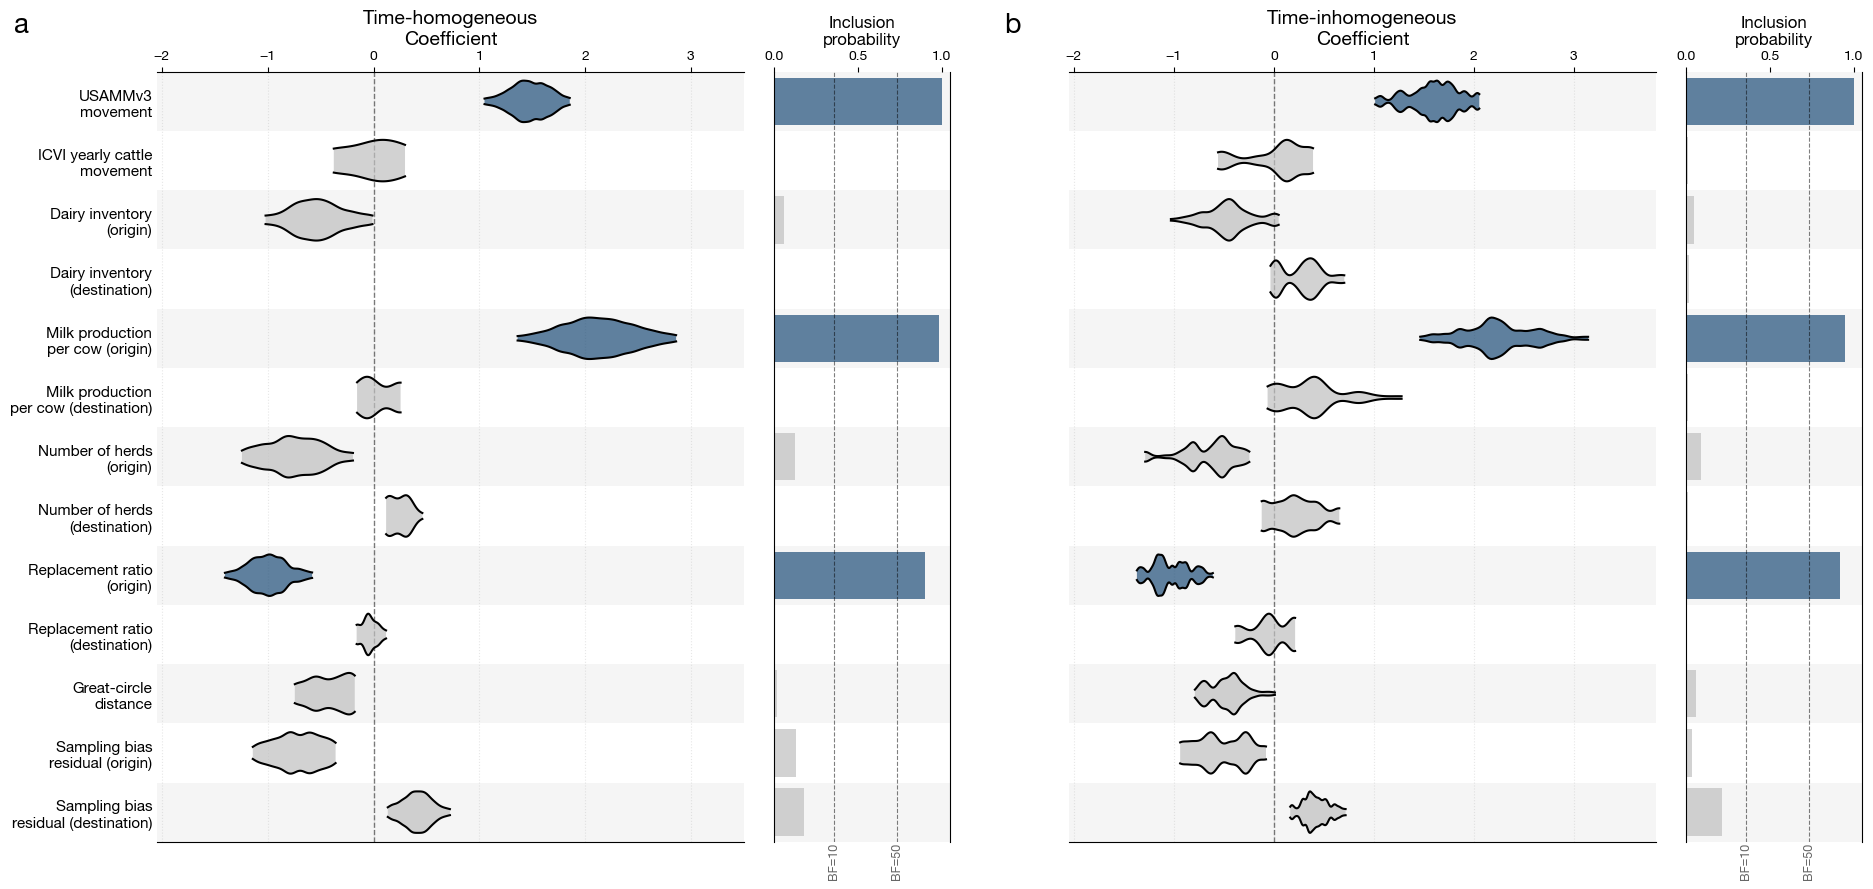

In [5]:
unified_predictors = [
    'usamm_movement', 'icvi_yearly_cattle_movement',
    'dairy_inventory_origin', 'dairy_inventory_destination',
    'milk_production_per_cow_origin', 'milk_production_per_cow_destination',
    'num_herds_origin', 'num_herds_destination',
    'replacement_ratio_origin', 'replacement_ratio_destination',
    'state_distances', 'sampling_bias_residual_origin', 'sampling_bias_residual_destination',
][::-1]


def plot_glm_panel(ax_coeff, ax_ip, predictors_in_run, GLM_coeffs, GLM_indicators,
                   GLM_conditional_coeffs, BFs, prior_odds, unified_preds, title):
    plotBFs = [10, 50]
    cutoffs = {}
    for bf in plotBFs:
        posteriorOdds = prior_odds * bf
        cutoffs[bf] = posteriorOdds / (1 + posteriorOdds)
        ax_ip.axvline(cutoffs[bf], color='k', lw=0.8, ls='--', alpha=0.5)
    for bf in plotBFs:
        ax_ip.text(cutoffs[bf], -0.5, f'BF={bf}', size=9, ha='center', va='top', rotation=90, alpha=0.6)
    leftedge = rightedge = 0
    for i, pred in enumerate(unified_preds):
        if pred not in predictors_in_run:
            ax_coeff.axhspan(i-0.5, i+0.5, facecolor='k', edgecolor='none', alpha=0.03, zorder=0)
            ax_ip.axhspan(i-0.5, i+0.5, facecolor='k', edgecolor='none', alpha=0.03, zorder=0)
            ax_coeff.text(0, i, 'n/a', ha='center', va='center', size=10, color='grey', style='italic')
            continue
        if i % 2 == 0:
            ax_coeff.axhspan(i-0.5, i+0.5, facecolor='k', edgecolor='none', alpha=0.04, zorder=0)
            ax_ip.axhspan(i-0.5, i+0.5, facecolor='k', edgecolor='none', alpha=0.04, zorder=0)
        support = np.mean(GLM_indicators[pred])
        cond_coeff = GLM_conditional_coeffs[pred]
        if len(cond_coeff) < 3:
            ax_ip.barh(i, support, height=0.8, align='center', edgecolor='none',
                       facecolor='#C0C0C0', alpha=0.7)
            continue
        w = 0.35
        k1 = gaussian_kde(cond_coeff)
        m1, M1 = hpd(cond_coeff, 0.95)
        leftedge = min(leftedge, m1)
        rightedge = max(rightedge, M1)
        x1 = np.linspace(m1, M1, 100)
        v1 = k1.evaluate(x1)
        v1 = v1 / v1.max() * w
        supportFrac = min(1.0, support / cutoffs[min(plotBFs)])
        fcolour = HIGHLIGHT_COLOR if support >= cutoffs[min(plotBFs)] else "#C0C0C0"
        ax_coeff.fill_between(x1, [i+q for q in v1], [i-q for q in v1],
                              facecolor=fcolour, edgecolor='none',
                              alpha=0.7, zorder=100)
        ax_coeff.plot(x1, [i+q for q in v1], color='k', lw=1.5, zorder=100)
        ax_coeff.plot(x1, [i-q for q in v1], color='k', lw=1.5, zorder=100)
        ip_color = HIGHLIGHT_COLOR if support >= cutoffs[min(plotBFs)] else '#C0C0C0'
        ax_ip.barh(i, support, height=0.8, align='center', edgecolor='none',
                   facecolor=ip_color, alpha=0.7)
    ax_coeff.axvline(0, ls='--', lw=1, color='k', alpha=0.5)
    ax_coeff.grid(axis='x', ls=':', alpha=0.3)
    ax_coeff.spines['right'].set_visible(False)
    ax_coeff.spines['left'].set_visible(False)
    ax_coeff.set_ylim(-0.5, len(unified_preds)-0.5)
    ax_ip.set_ylim(-0.5, len(unified_preds)-0.5)
    margin = max(0.3, (rightedge - leftedge) * 0.15)
    ax_coeff.set_xlim(leftedge - margin, rightedge + margin)
    ax_ip.set_xlim(0, 1.05)
    ax_coeff.xaxis.set_label_position('top'); ax_coeff.xaxis.tick_top()
    ax_coeff.set_xlabel('Coefficient', size=14, weight=400)
    ax_coeff.tick_params(axis='x', labelsize=10); ax_coeff.tick_params(axis='y', size=0)
    ax_ip.xaxis.set_label_position('top'); ax_ip.xaxis.tick_top()
    ax_ip.set_xlabel('Inclusion\nprobability', size=12, weight=400)
    ax_ip.set_xticks([0, 0.5, 1.0]); ax_ip.tick_params(axis='x', labelsize=10)
    ax_ip.tick_params(axis='y', size=0); ax_ip.set_yticklabels([])
    ax_ip.spines['top'].set_visible(False); ax_ip.spines['bottom'].set_visible(False)
    ax_coeff.set_title(title, size=14, weight=400, pad=35)


fig = plt.figure(figsize=(22, 10))
# gs = gridspec.GridSpec(1, 4, width_ratios=[4, 1.2, 4, 1.2], wspace=0.15)
# ax1, ax2, ax3, ax4 = [plt.subplot(gs[i]) for i in range(4)]

outer = gridspec.GridSpec(1, 2, wspace=0.15)  # gap between A and B
gs_left = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0], width_ratios=[4, 1.2], wspace=0.08)
gs_right = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1], width_ratios=[4, 1.2], wspace=0.08)

ax1 = fig.add_subplot(gs_left[0])   # A coefficient
ax2 = fig.add_subplot(gs_left[1])   # A IP
ax3 = fig.add_subplot(gs_right[0])  # B coefficient
ax4 = fig.add_subplot(gs_right[1])  # B IP

ylabels = [predictor_labels_13.get(p, p) for p in unified_predictors]
ax1.set_yticks(range(len(unified_predictors))); ax1.set_yticklabels(ylabels, size=11)
ax3.set_yticks(range(len(unified_predictors))); ax3.set_yticklabels([])

plot_glm_panel(ax1, ax2, set(homog_predictors), homog_coeffs, homog_indicators,
               homog_cond_coeffs, homog_BFs, homog_prior_odds, unified_predictors, 'Time-homogeneous')
plot_glm_panel(ax3, ax4, set(inhomog_predictors), inhomog_coeffs, inhomog_indicators,
               inhomog_cond_coeffs, inhomog_BFs, inhomog_prior_odds, unified_predictors, 'Time-inhomogeneous')

# Panel labels
fig.text(0.06, 0.94, 'a', fontsize=20, fontweight='bold', va='top', ha='left')
fig.text(0.51, 0.94, 'b', fontsize=20, fontweight='bold', va='top', ha='left')

# fig.savefig(FIG_DIR / 'glm_bothMvmts_comparison.pdf', dpi=150, bbox_inches='tight')
# fig.savefig(FIG_DIR / 'glm_bothMvmts_comparison.png', dpi=200, bbox_inches='tight')
# print(f'Saved to {FIG_DIR}')
plt.show()

## Figure B: correlateSet2 3-era (enforced vs indicator)

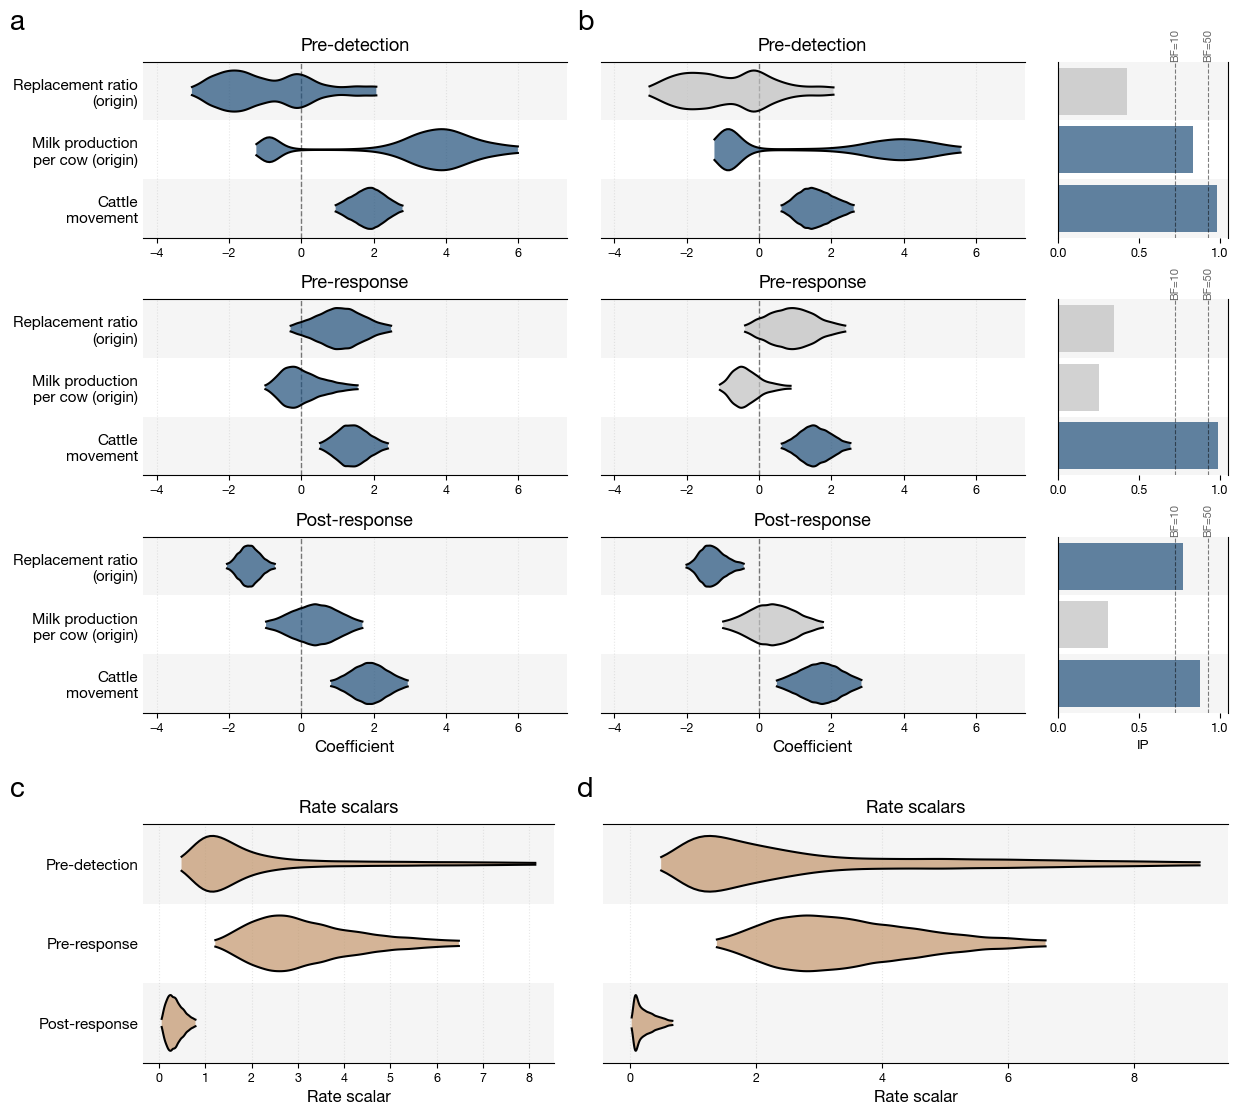

In [6]:
def get_coeff_xlim(results, eras, preds):
    leftedge = rightedge = 0
    for era in eras:
        for pred in preds:
            cond = results[era]['cond_coeffs'][pred]
            if len(cond) < 3: continue
            m1, M1 = hpd(cond, 0.95)
            leftedge = min(leftedge, m1)
            rightedge = max(rightedge, M1)
    margin = max(0.5, (rightedge - leftedge) * 0.15)
    return leftedge - margin, rightedge + margin


def plot_coeff_panel(ax, era_results, preds, prior_odds, show_ylabels=True,
                     show_xlabel=True, title='', ip_threshold=None, bf_threshold=10, xlim=None):
    if ip_threshold is None:
        ip_threshold = bf_to_pp(bf_threshold, prior_odds)
    for i, pred in enumerate(preds):
        if i % 2 == 0:
            ax.axhspan(i-0.5, i+0.5, facecolor='k', edgecolor='none', alpha=0.04, zorder=0)
        cond = era_results['cond_coeffs'][pred]
        support = np.mean(era_results['indicators'][pred])
        if len(cond) < 3: continue
        w = 0.35
        k1 = gaussian_kde(cond)
        m1, M1 = hpd(cond, 0.95)
        x1 = np.linspace(m1, M1, 100)
        v1 = k1.evaluate(x1); v1 = v1/v1.max()*w
        fcolour = HIGHLIGHT_COLOR if support >= ip_threshold else '#C0C0C0'
        ax.fill_between(x1, [i+q for q in v1], [i-q for q in v1],
                        facecolor=fcolour, edgecolor='none', alpha=0.7, zorder=100)
        ax.plot(x1, [i+q for q in v1], color='k', lw=1.5, zorder=100)
        ax.plot(x1, [i-q for q in v1], color='k', lw=1.5, zorder=100)
    ax.axvline(0, ls='--', lw=1, color='k', alpha=0.5)
    ax.grid(axis='x', ls=':', alpha=0.3)
    ax.spines['right'].set_visible(False); ax.spines['left'].set_visible(False)
    ax.set_ylim(-0.5, len(preds)-0.5)
    if xlim: ax.set_xlim(xlim)
    if show_xlabel: ax.set_xlabel('Coefficient', size=12, weight=400)
    ax.tick_params(axis='x', labelsize=9); ax.tick_params(axis='y', size=0)
    ax.set_yticks(range(len(preds)))
    if show_ylabels: ax.set_yticklabels([cs2_labels.get(p, p) for p in preds], size=11)
    else: ax.set_yticklabels([])
    if title: ax.set_title(title, size=13, weight=400, pad=8)


def plot_ip_panel(ax, era_results, preds, prior_odds, show_xlabel=True):
    plotBFs = [10, 50]
    cutoffs = {bf: bf_to_pp(bf, prior_odds) for bf in plotBFs}
    for bf in plotBFs:
        ax.axvline(cutoffs[bf], color='k', lw=0.8, ls='--', alpha=0.5)
        ax.text(cutoffs[bf], len(preds)-0.5, f'BF={bf}', size=8, ha='center', va='bottom', rotation=90, alpha=0.6)
    bf10_pp = cutoffs[10]
    for i, pred in enumerate(preds):
        if i % 2 == 0:
            ax.axhspan(i-0.5, i+0.5, facecolor='k', edgecolor='none', alpha=0.04, zorder=0)
        support = np.mean(era_results['indicators'][pred])
        ip_color = HIGHLIGHT_COLOR if support >= bf10_pp else '#C0C0C0'
        ip_alpha = 0.7
        ax.barh(i, support, height=0.8, align='center', edgecolor='none', facecolor=ip_color, alpha=ip_alpha)
    ax.set_ylim(-0.5, len(preds)-0.5); ax.set_xlim(0, 1.05)
    if show_xlabel: ax.set_xlabel('IP', size=10, weight=400)
    ax.set_xticks([0, 0.5, 1.0]); ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', size=0); ax.set_yticklabels([])
    ax.spines['top'].set_visible(False); ax.spines['bottom'].set_visible(False)


def plot_rate_scalar_panel(ax, rate_scalars, eras_list_input, show_ylabels=True, show_xlabel=True, title='Rate scalars'):
    eras_list = list(reversed(eras_list_input))
    era_display = {'cryptic': 'Pre-detection', 'expansion': 'Pre-response', 'post': 'Post-response'}
    for i, era in enumerate(eras_list):
        if i % 2 == 0:
            ax.axhspan(i-0.5, i+0.5, facecolor='k', edgecolor='none', alpha=0.04, zorder=0)
        rs = rate_scalars[era]
        if len(rs) < 3: continue
        w = 0.35
        k1 = gaussian_kde(rs)
        m1, M1 = hpd(rs, 0.95)
        x1 = np.linspace(m1, M1, 100)
        v1 = k1.evaluate(x1); v1 = v1/v1.max()*w
        ax.fill_between(x1, [i+q for q in v1], [i-q for q in v1],
                        facecolor='#c2956b', edgecolor='none', alpha=0.7, zorder=100)
        ax.plot(x1, [i+q for q in v1], color='k', lw=1.5, zorder=100)
        ax.plot(x1, [i-q for q in v1], color='k', lw=1.5, zorder=100)
    ax.grid(axis='x', ls=':', alpha=0.3)
    ax.spines['right'].set_visible(False); ax.spines['left'].set_visible(False)
    ax.set_ylim(-0.5, len(eras_list)-0.5)
    if show_xlabel: ax.set_xlabel('Rate scalar', size=12, weight=400)
    ax.tick_params(axis='x', labelsize=9); ax.tick_params(axis='y', size=0)
    ax.set_yticks(range(len(eras_list)))
    if show_ylabels: ax.set_yticklabels([era_display[e] for e in eras_list], size=11)
    else: ax.set_yticklabels([])
    if title: ax.set_title(title, size=13, weight=400, pad=8)


# Shared coefficient limits
enf_xlim = get_coeff_xlim(enf_results, cs2_eras, cs2_predictors)
ind_xlim = get_coeff_xlim(ind_results, cs2_eras, cs2_predictors)
shared_xlim = (min(enf_xlim[0], ind_xlim[0]), max(enf_xlim[1], ind_xlim[1]))

fig = plt.figure(figsize=(14, 13))
outer = gridspec.GridSpec(2, 1, height_ratios=[3, 1.1], hspace=0.25)
gs = gridspec.GridSpecFromSubplotSpec(3, 3, subplot_spec=outer[0],
                                      width_ratios=[3, 3, 1.2], hspace=0.35, wspace=0.1)
gs_rs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[1],
                                         width_ratios=[3, 3, 1.2], wspace=0.15)

for row_idx, era in enumerate(cs2_eras):
    is_bottom = (row_idx == 2)
    ax_enf = fig.add_subplot(gs[row_idx, 0])
    plot_coeff_panel(ax_enf, enf_results[era], cs2_predictors, enf_prior_odds,
                     show_ylabels=True, show_xlabel=is_bottom,
                     title=era_labels[era], ip_threshold=0.0, xlim=shared_xlim)
    ax_ind = fig.add_subplot(gs[row_idx, 1])
    plot_coeff_panel(ax_ind, ind_results[era], cs2_predictors, ind_prior_odds,
                     show_ylabels=False, show_xlabel=is_bottom,
                     title=era_labels[era], xlim=shared_xlim)
    ax_ip = fig.add_subplot(gs[row_idx, 2])
    plot_ip_panel(ax_ip, ind_results[era], cs2_predictors, ind_prior_odds, show_xlabel=is_bottom)

ax_rs_enf = fig.add_subplot(gs_rs[0, 0])
plot_rate_scalar_panel(ax_rs_enf, enf_rates, cs2_eras, show_ylabels=True, title='Rate scalars')
ax_rs_ind = fig.add_subplot(gs_rs[0, 1:])
plot_rate_scalar_panel(ax_rs_ind, ind_rates, cs2_eras, show_ylabels=False, title='Rate scalars')

# Panel labels
fig.text(0.03, 0.92, 'a', fontsize=20, fontweight='bold', va='top', ha='left')
fig.text(0.435, 0.92, 'b', fontsize=20, fontweight='bold', va='top', ha='left')
fig.text(0.03, 0.33, 'c', fontsize=20, fontweight='bold', va='top', ha='left')
fig.text(0.435, 0.33, 'd', fontsize=20, fontweight='bold', va='top', ha='left')

# fig.savefig(FIG_DIR / 'glm_correlateSet2_3era_combined.pdf', dpi=150, bbox_inches='tight')
# fig.savefig(FIG_DIR / 'glm_correlateSet2_3era_combined.png', dpi=200, bbox_inches='tight')
# print(f'Saved to {FIG_DIR}')
plt.show()

## Summary tables

In [7]:
# bothMvmts summary
rows = []
for pred in unified_predictors[::-1]:
    row = {'Predictor': predictor_labels_13.get(pred, pred).replace('\n', ' ')}
    for label, coeffs, indicators, cond, bfs in [
        ('Homog', homog_coeffs, homog_indicators, homog_cond_coeffs, homog_BFs),
        ('Inhomog', inhomog_coeffs, inhomog_indicators, inhomog_cond_coeffs, inhomog_BFs),
    ]:
        if pred in bfs:
            s = np.mean(indicators[pred])
            c = cond[pred]
            if len(c) >= 3:
                h = hpd(c, 0.95)
                row[f'{label} coeff'] = f'{np.mean(c):.2f}'
                row[f'{label} HPD'] = f'[{h[0]:.2f}, {h[1]:.2f}]'
            else:
                row[f'{label} coeff'] = 'n/a'
                row[f'{label} HPD'] = 'n/a'
            row[f'{label} IP'] = f'{s:.4f}'
            row[f'{label} BF'] = f'>{50:.0f}' if bfs[pred] > 50 else f'{bfs[pred]:.2f}'
        else:
            for col in ['coeff', 'HPD', 'IP', 'BF']:
                row[f'{label} {col}'] = '-'
    rows.append(row)
print('=== bothMvmts comparison ===')
display(pd.DataFrame(rows))

=== bothMvmts comparison ===


,Predictor,Homog coeff,Homog HPD,Homog IP,Homog BF,Inhomog coeff,Inhomog HPD,Inhomog IP,Inhomog BF
0,USAMMv3 movement,1.49,"[1.05, 1.85]",1.0000,>50,1.61,"[1.01, 2.06]",1.0000,>50
1,ICVI yearly cattle movement,-0.01,"[-0.38, 0.30]",0.0008,0.01,0.03,"[-0.56, 0.39]",0.0080,0.15
2,Dairy inventory (origin),-0.52,"[-1.02, -0.01]",0.0552,1.06,-0.46,"[-1.03, 0.05]",0.0447,0.85
3,Dairy inventory (destination),n/a,n/a,0.0000,-0.00,0.27,"[-0.03, 0.71]",0.0136,0.25
4,Milk production per cow (origin),2.14,"[1.36, 2.86]",0.9817,>50,2.24,"[1.46, 3.14]",0.9494,>50
5,Milk production per cow (destination),0.05,"[-0.16, 0.26]",0.0018,0.03,0.41,"[-0.06, 1.28]",0.0113,0.21
6,Number of herds (origin),-0.75,"[-1.24, -0.19]",0.1211,2.51,-0.62,"[-1.29, -0.24]",0.0903,1.81
7,Number of herds (destination),0.23,"[0.12, 0.46]",0.0031,0.05,0.21,"[-0.12, 0.66]",0.0098,0.18
8,Replacement ratio (origin),-0.99,"[-1.40, -0.58]",0.9005,>50,-1.02,"[-1.37, -0.61]",0.9162,>50
9,Replacement ratio (destination),-0.04,"[-0.16, 0.12]",0.0063,0.11,-0.03,"[-0.38, 0.21]",0.0028,0.05


In [8]:
# correlateSet2 summary
def build_cs2_table(results, rate_scalars, prior_odds, run_label):
    rows = []
    for era in cs2_eras:
        for pred in cs2_predictors:
            row = {'Run': run_label, 'Era': era_labels[era],
                   'Predictor': cs2_labels[pred].replace('\n', ' ')}
            support = np.mean(results[era]['indicators'][pred])
            cond = results[era]['cond_coeffs'][pred]
            if len(cond) >= 3:
                h = hpd(cond, 0.95)
                row['Coeff'] = f'{np.mean(cond):.2f}'
                row['95% HPD'] = f'[{h[0]:.2f}, {h[1]:.2f}]'
            else:
                row['Coeff'] = 'n/a'; row['95% HPD'] = 'n/a'
            row['IP'] = f'{support:.4f}'
            L = len(results[era]['indicators'][pred])
            po = (support - 1.0/L) / (1.0 - (support - 1.0/L))
            bf = po / prior_odds
            row['BF'] = f'>{50:.0f}' if bf > 50 else f'{bf:.2f}'
            rows.append(row)
        rs = rate_scalars[era]
        h = hpd(rs, 0.95)
        rows.append({'Run': run_label, 'Era': era_labels[era], 'Predictor': 'RATE SCALAR',
                     'Coeff': f'{np.mean(rs):.4f}', '95% HPD': f'[{h[0]:.4f}, {h[1]:.4f}]',
                     'IP': '-', 'BF': '-'})
    return rows

print('=== correlateSet2 3-era comparison ===')
display(pd.DataFrame(build_cs2_table(ind_results, ind_rates, ind_prior_odds, 'Indicator') +
                     build_cs2_table(enf_results, enf_rates, enf_prior_odds, 'Enforced')))

=== correlateSet2 3-era comparison ===


,Run,Era,Predictor,Coeff,95% HPD,IP,BF
0,Indicator,Pre-detection,Cattle movement,1.58,"[0.62, 2.61]",0.9848,>50
1,Indicator,Pre-detection,Milk production per cow (origin),2.09,"[-1.24, 5.57]",0.8316,18.99
2,Indicator,Pre-detection,Replacement ratio (origin),-0.76,"[-3.03, 2.06]",0.4245,2.84
3,Indicator,Pre-detection,RATE SCALAR,3.2805,"[0.4942, 9.0408]",-,-
4,Indicator,Pre-response,Cattle movement,1.58,"[0.62, 2.52]",0.9867,>50
5,Indicator,Pre-response,Milk production per cow (origin),-0.28,"[-1.09, 0.87]",0.2485,1.27
6,Indicator,Pre-response,Replacement ratio (origin),0.97,"[-0.39, 2.38]",0.3441,2.02
7,Indicator,Pre-response,RATE SCALAR,3.6428,"[1.3785, 6.5959]",-,-
8,Indicator,Post-response,Cattle movement,1.70,"[0.49, 2.83]",0.8761,27.20
9,Indicator,Post-response,Milk production per cow (origin),0.34,"[-1.00, 1.76]",0.3093,1.72
